## Tarea 5

### Sección 3 <br> Conjunto de datos de cáncer desde Scikit-learn

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

Para identificar el tipo de tumor que se corresponde con el valor `0` y `1` de la columna `target` se puede hacer lo siguiente:

In [3]:
cancer = load_breast_cancer()
target_labels = cancer.target[[10, 50, 85]]
print("Numerical labels:", target_labels)
print("Class names:", cancer.target_names[target_labels])

Numerical labels: [0 1 0]
Class names: ['malignant' 'benign' 'malignant']


Lo anterior indica que:
* target = `0` --> Maligno
* target = `1` --> Benigno

**Nota importante**:

En `sklearn`, por convención, la clase positiva es **el número más alto**, es decir:

* Clase positiva (`1`) = Benigno
* Clase negativa (`0`) = Maligno

Más adelante se usará la función `precision_recall_curve()`, y por la convención de `sklearn` dicha función evalúa la habilidad del modelo para detectar casos benignos (no cáncer).

Como en la presente entrega se quiere evaluar un modelo para la detección de casos malignos (cáncer) se invertirá el target, es decir:

* Clase positiva (`1`) = Maligno
* Clase negativa (`0`) = Benigno

In [4]:
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = 1 - cancer.target # 0 = Benigno, 1 = Maligno
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

#### Sección 3.1 <br> Variables y su correlación con el diagnóstico

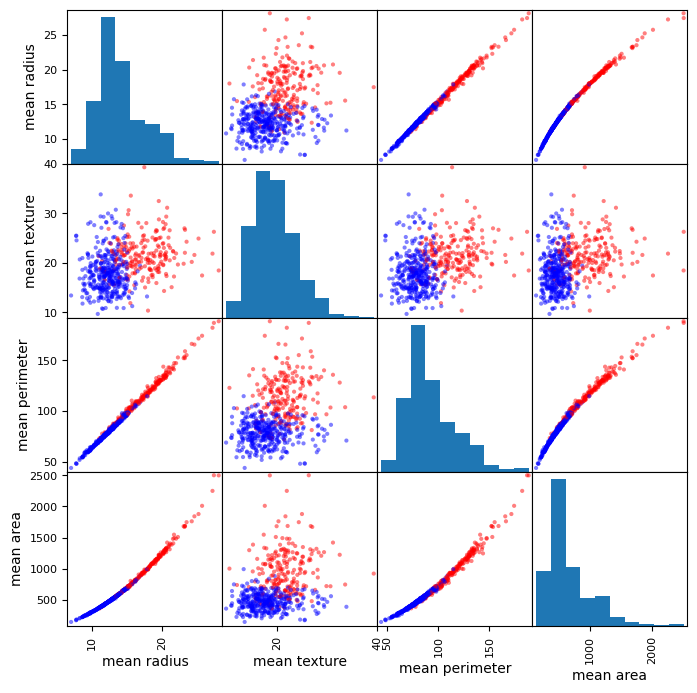

In [5]:
# from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df.iloc[:, :4], c=df['target'], cmap='bwr', figsize=(8,8))
plt.show()

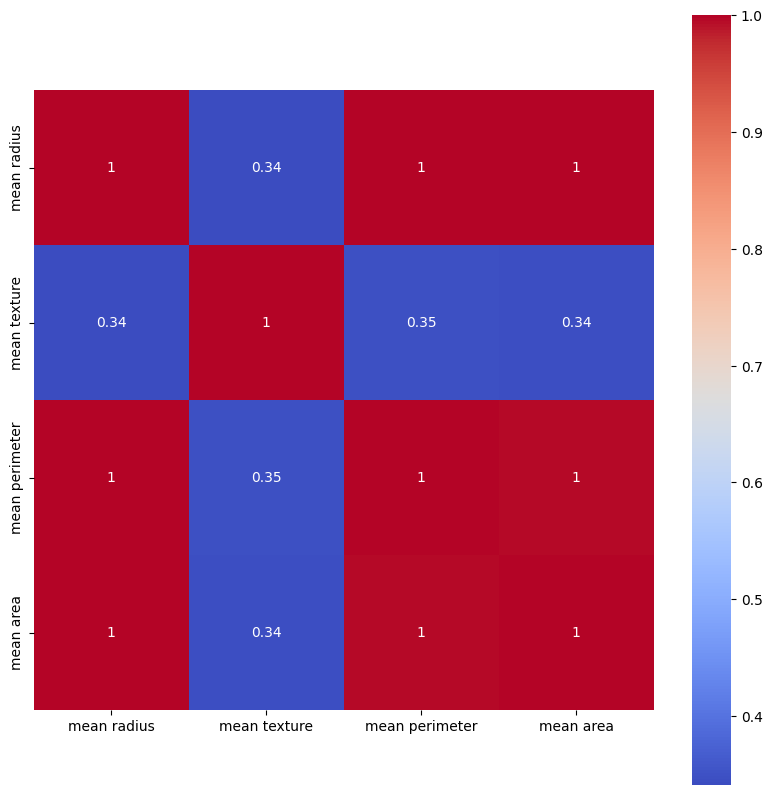

In [6]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(df.iloc[:, 0:4].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.show()

#### Sección 3.2 <br> Matriz de confusión

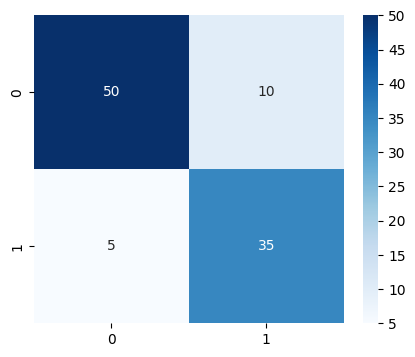

In [7]:
cm = [[50, 10], [5, 35]]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

#### Sección 3.3 <br> Métricas de evaluación

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df['target'], df['prediction'])
precision = precision_score(df['target'], df['prediction'])
recall = recall_score(df['target'], df['prediction'])
f1 = f1_score(df['target'], df['prediction'])
```

#### Sección 3.4 <br> Estudio de umbral

##### 3.4.1
Seleccionar __tres__ variables del conjunto con diferente correlación con el diagnóstico: una de alta correlación, una de correlación media y una de baja correlación. Para ello calcula la matriz de correlación y ordena los valores en orden descendente. Puedes usar `df.corr()[['target']]` para obtener la correlación de todas las variables con el diagnóstico (target).

En `df_correlacion` guardamos el DataFrame de la correlación de todas las variables con `target`. Después de ordenarlas de forma descendente consideramos todas las filas excepto la primera `[1:]`, pues la primera corresponde a la correlación de _target_ con _target_.

Nótese que se ordenan los valores en valor absoluto.

In [8]:
df_correlacion = df.corr()[['target']].sort_values(by='target', key=lambda x: abs(x), ascending=False)[1:]

# Variable con alta correlación
alta_corr = df_correlacion.iloc[0]

# Variable con media correlación (tomamos la décima variable solo por tomar alguna que esté entre la de alta y baja correlación)
media_corr = df_correlacion.iloc[10]

# Variable con baja correlación
baja_corr = df_correlacion.iloc[-1]

print(f'''
Variable con alta correlación: {alta_corr.name}
Variable con media correlación: {media_corr.name}
Variable con baja correlación: {baja_corr.name}
''')


Variable con alta correlación: worst concave points
Variable con media correlación: mean compactness
Variable con baja correlación: symmetry error



##### 3.4.2
Estudia las tres variables, puedes usar `df['VARIABLE'].describe()` para analizar su distribución y valores estadísticos.

Sin considerar distinción en el target

In [9]:
df[[alta_corr.name, media_corr.name, baja_corr.name]].describe()

,worst concave points,mean compactness,symmetry error
count,569.000000,569.000000,569.000000
mean,0.114606,0.104341,0.020542
std,0.065732,0.052813,0.008266
min,0.000000,0.019380,0.007882
25%,0.064930,0.064920,0.015160
50%,0.099930,0.092630,0.018730
75%,0.161400,0.130400,0.023480
max,0.291000,0.345400,0.078950


Considerando distinción en el target

In [10]:
df.groupby("target")[[alta_corr.name]].describe()

worst concave points                                                 \
                      count      mean       std      min      25%      50%   
target                                                                       
0                     357.0  0.074444  0.035797  0.00000  0.05104  0.07431   
1                     212.0  0.182237  0.046308  0.02899  0.15275  0.18200   

                         
             75%    max  
target                   
0       0.097490  0.175  
1       0.210675  0.291

In [11]:
df.groupby("target")[[media_corr.name]].describe()

mean compactness                                                 \
                  count      mean       std      min      25%      50%   
target                                                                   
0                 357.0  0.080085  0.033750  0.01938  0.05562  0.07529   
1                 212.0  0.145188  0.053987  0.04605  0.10960  0.13235   

                         
            75%     max  
target                   
0       0.09755  0.2239  
1       0.17240  0.3454

In [12]:
df.groupby("target")[[baja_corr.name]].describe()

symmetry error                                                   \
                count      mean       std       min       25%      50%   
target                                                                   
0               357.0  0.020584  0.006999  0.009539  0.015600  0.01909   
1               212.0  0.020472  0.010065  0.007882  0.014615  0.01770   

                           
             75%      max  
target                     
0       0.024060  0.06146  
1       0.022132  0.07895

##### 3.4.3

Dibuja las variables para tumores malignos y benignos, y usa la estimación de densidad de kernel (KDE) para visualizar su distribución.

Recordemos que: 
* target = 0 es benigno
* target = 1 es maligno

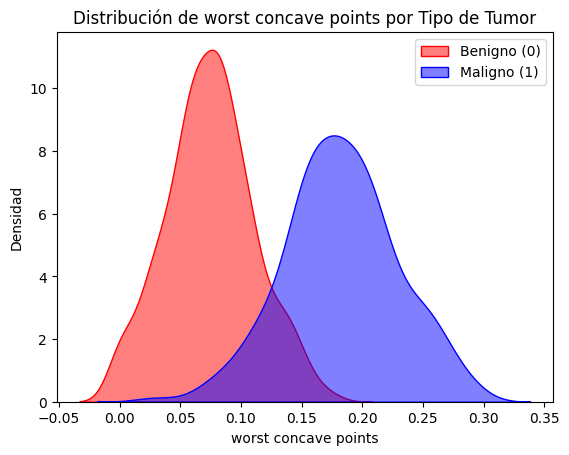

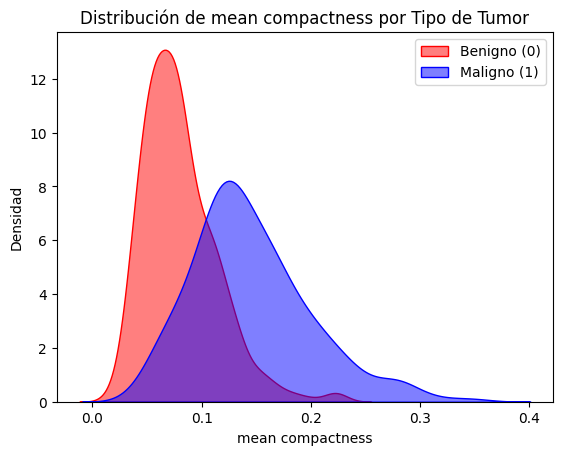

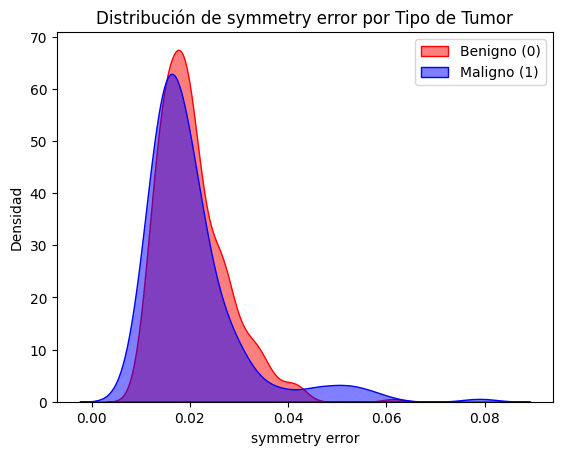

In [13]:
for name in [alta_corr.name, media_corr.name, baja_corr.name]:

    # plt.figure(figsize=(8, 5))
    sns.kdeplot(df[df['target'] == 0][name], label="Benigno (0)", fill=True, color="red", alpha=0.5)
    sns.kdeplot(df[df['target'] == 1][name], label="Maligno (1)", fill=True, color="blue", alpha=0.5)
    plt.xlabel(name)
    plt.ylabel("Densidad")
    plt.title("Distribución de " + name + " por Tipo de Tumor")
    plt.legend()
    plt.show()

##### 3.4.4

El siguiente paso es evaluar qué tan bien predicen si un tumor es Maligno (M) o Benigno (B). Para hacerlo de manera sencilla, podemos comparar esta variable con el diagnóstico real (target) y calcular la matriz de confusión y las metricas.

##### 3.4.5

Escoge "a ojo" un valor de umbral para cada variable que te ayudará a clasificar los tumores como malignos (M = 1) o benignos (B = 0).

##### 3.4.6

Ahora asigna etiquetas de clasificación o predicción, esto significa que definas un `df['prediction']` tal que: si el valor de variable es menor o igual al umbral, predice B (Benigno). Si el valor de variable es mayor al umbral, predice M (Maligno).

Para definir el valor umbral para las tres variables con las que estamos trabajando tomaremos aquel valor que "a ojo" separe las distribuciones de cada tipo de tumor.

* Para _worst concave points_: 0.12
* Para _mean compactness_: 0.1
* Para _symmetry error_: 0.02

Columnas generadas:
* *prediccion_alta_corr*: Predicción obtenida con el umbral de _worst concave points_.
* *prediccion_media_corr*: Predicción obtenida con el umbral de _mean compactness_.
* *prediccion_baja_corr*: Predicción obtenida con el umbral de _symmetry error_.


> `DataFrame.astype(int)` para convertir booleano a entero:
> * `int(False) -> 0`
> * `int(True) -> 1`  

In [69]:
alta_corr_umbral = 0.12
media_corr_umbral = 0.1
baja_corr_umbral = 0.02

df['prediccion_alta_corr'] = (df[alta_corr.name] > alta_corr_umbral).astype(int)  # 0 = Benigno, 1 = Maligno
df['prediccion_media_corr'] = (df[media_corr.name] > media_corr_umbral).astype(int)
df['prediccion_baja_corr'] = (df[baja_corr.name] > baja_corr_umbral).astype(int)

##### 3.4.7

Imprime las primeras 30 filas con los valores reales del diagnóstico y las predicciones generadas. 
¿Por qué hay casos con target = 0 (Benigno) que tienen prediction = 1 (Maligno)?

La predicción la realizamos tomando "a ojo" un valor umbral para cada variable; esta predicción depende del umbral y la correlación que tiene dicha variable con el target:

* Si la correlación es alta: Las distribuciones por tipo de tumor de la variable en cuestión tienen una clara separación tal que es fácil elegir un valor umbral que logre separarlas. Por ende, el valor umbral logra una buena clasificación entre tumores.
* Si la correlación es baja: Las distribuciones por tipo de tumor de la variable en cuestión se superponen haciendo difícil la elección de un umbral para la clasificación entre tumores. Por ende, el valor umbral no logra una buena clasificación entre tumores.

Notemos que la predicción no es perfecta pues la estamos realizando en función de un valor umbral por variable; hay valores en la distribución por tumor que se superponen y que el criterio puede clasificar de manera incorrecta.

In [70]:
df[[alta_corr.name, media_corr.name, baja_corr.name, 'prediccion_alta_corr', 'prediccion_media_corr', 'prediccion_baja_corr', 'target']].head(30)

,worst concave points,mean compactness,symmetry error,prediccion_alta_corr,prediccion_media_corr,prediccion_baja_corr,target
0,0.26540,0.27760,0.03003,1,1,1,1
1,0.18600,0.07864,0.01389,1,0,0,1
2,0.24300,0.15990,0.02250,1,1,1,1
3,0.25750,0.28390,0.05963,1,1,1,1
4,0.16250,0.13280,0.01756,1,1,0,1
5,0.17410,0.17000,0.02165,1,1,1,1
6,0.19320,0.10900,0.01369,1,1,0,1
7,0.15560,0.16450,0.01486,1,1,0,1
8,0.20600,0.19320,0.02143,1,1,1,1
9,0.22100,0.23960,0.01789,1,1,0,1


##### 3.4.8

Define FP: casos donde el target real es 0 (Benigno) pero la predicción es 1 (Maligno). 

Define FN: casos donde el target real es 1 (Maligno) pero la predicción es 0 (Benigno). 

Cuéntalos y encuentra cuantas predicciones fallaron.

Recordemos que tenemos un total de **569** datos.

In [71]:
# Para worst concave points
FP_alta_corr = df[(df['target'] == 0) & (df['prediccion_alta_corr'] == 1)]
FN_alta_corr = df[(df['target'] == 1) & (df['prediccion_alta_corr'] == 0)]
TN_alta_corr = df[(df['target'] == 0) & (df['prediccion_alta_corr'] == 0)]
TP_alta_corr = df[(df['target'] == 1) & (df['prediccion_alta_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.
""".format(alta_corr.name, FP_alta_corr.shape[0], FN_alta_corr.shape[0], FP_alta_corr.shape[0] + FN_alta_corr.shape[0]))

# Para mean compactness
FP_media_corr = df[(df['target'] == 0) & (df['prediccion_media_corr'] == 1)]
FN_media_corr = df[(df['target'] == 1) & (df['prediccion_media_corr'] == 0)]
TN_media_corr = df[(df['target'] == 0) & (df['prediccion_media_corr'] == 0)]
TP_media_corr = df[(df['target'] == 1) & (df['prediccion_media_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.  
""".format(media_corr.name, FP_media_corr.shape[0], FN_media_corr.shape[0], FP_media_corr.shape[0] + FN_media_corr.shape[0]))

# Para symmetry error
FP_baja_corr = df[(df['target'] == 0) & (df['prediccion_baja_corr'] == 1)]
FN_baja_corr = df[(df['target'] == 1) & (df['prediccion_baja_corr'] == 0)]
TN_baja_corr = df[(df['target'] == 0) & (df['prediccion_baja_corr'] == 0)]
TP_baja_corr = df[(df['target'] == 1) & (df['prediccion_baja_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.  
""".format(baja_corr.name, FP_baja_corr.shape[0], FN_baja_corr.shape[0], FP_baja_corr.shape[0] + FN_baja_corr.shape[0]))


Para worst concave points hay: 
40 predicciones FP
19 predicciones FN
Son 59 predicciones que fallaron.


Para mean compactness hay: 
86 predicciones FP
36 predicciones FN
Son 122 predicciones que fallaron.  


Para symmetry error hay: 
152 predicciones FP
135 predicciones FN
Son 287 predicciones que fallaron.  



##### 3.4.9

Dibuja la matriz de confusión completa.

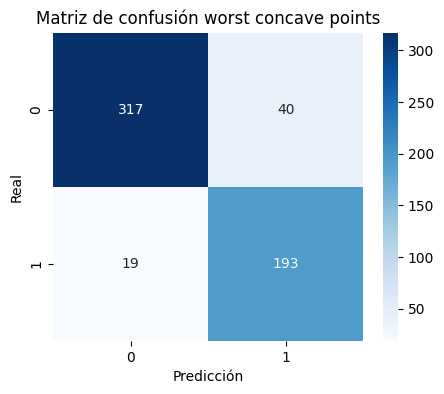

In [72]:
# Para worst concave points
mc_alta_corr = [[TN_alta_corr.shape[0], FP_alta_corr.shape[0]],
                [FN_alta_corr.shape[0], TP_alta_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_alta_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+alta_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

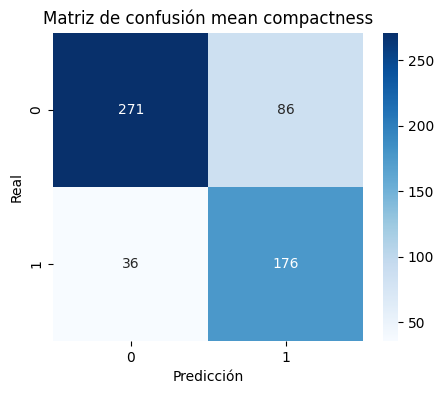

In [73]:
# Para mean compactness
mc_media_corr = [[TN_media_corr.shape[0], FP_media_corr.shape[0]],
                [FN_media_corr.shape[0], TP_media_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_media_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+media_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

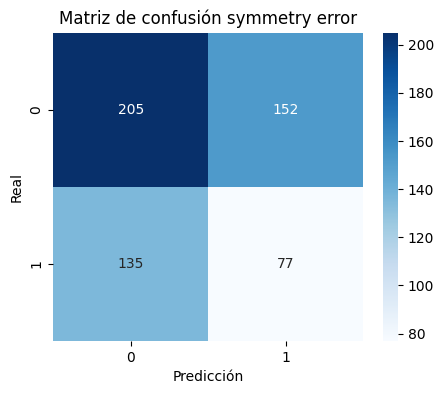

In [74]:
# Para symmetry error
mc_baja_corr = [[TN_baja_corr.shape[0], FP_baja_corr.shape[0]],
                [FN_baja_corr.shape[0], TP_baja_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_baja_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+baja_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

##### 3.4.10

Evalua todas las 4 metricas que apenas vimos. 
¿Tu modelo es confiable?

**Resumen sobre las métricas**

* **Accuracy (Exactitud)**
    * Mide la proporción de instancias correctamente clasificadas sobre el total.
    *  Es útil cuando la distribución de clases está equilibrada, pero puede ser engañosa si hay clases desbalanceadas.

* **Precision (Precisión)**
    * Mide la proporción de predicciones positivas que realmente son positivas.
    * Es útil cuando el costo de un falso positivo es alto (ejemplo: diagnóstico de cáncer, donde un falso positivo podría llevar a tratamientos innecesarios).

* **Recall (Sensibilidad o Exhaustividad)**
    * Mide la proporción de casos positivos que fueron correctamente identificados.
    * Es útil cuando el costo de un falso negativo es alto (ejemplo: en cáncer, un falso negativo significaría no detectar la enfermedad).

* **F1 Score**
    * Es la media armónica entre precisión y recall, proporcionando un balance entre ambas métricas.
    * Es útil cuando hay un desequilibrio entre clases y queremos equilibrar precisión y recall.

**Resultados**

Los resultados que obtuvimos muestran cómo diferentes variables del dataset afectan el rendimiento de un modelo de clasificación cuando se usan individualmente:

* **Variable: worst concave points**
    * accuracy: 0.896 → El modelo tiene una precisión general del 89.6%, lo que indica un buen rendimiento.
    * precision: 0.828 → De todas las veces que predijo la clase positiva, acertó el 82.8%.
    * recall: 0.910 → Capturó el 91.0% de los casos positivos reales.
    * F1 score: 0.867 → El balance entre precisión y recall es alto, indicando un modelo sólido.
    * Conclusión: Esta variable es un buen predictor del diagnóstico, ya que tiene una alta precisión y un buen equilibrio entre recall y precisión.

* **Variable: mean compactness**
    * accuracy: 0.785 → El modelo tiene una precisión global del 78.5%, más baja que la variable anterior.
    * precision: 0.672 → De las veces que predijo la clase positiva, acertó solo el 67.2%.
    * recall: 0.830 → Capturó el 83.0% de los casos positivos reales.
    * F1 score: 0.743 → Buen balance, pero menor que la variable anterior.
    * Conclusión: Aunque la sensibilidad (recall) es relativamente alta, la precisión es menor, lo que indica que este predictor puede estar generando más falsos positivos. Puede ser útil en algunos casos, pero no es tan fuerte como _worst concave points_.

* **Variable symmetry error**
    * accuracy: 0.495 → Solo acierta el 49.5% del tiempo, prácticamente equivalente a adivinar al azar.
    * precision: 0.336 → Cuando predijo la clase positiva, solo el 33.6% fue correcto.
    * recall: 0.363 → Solo detectó el 36.3% de los casos positivos reales.
    * F1 score: 0.349 → Mal equilibrio entre precisión y recall.
    * Conclusión: Esta variable tiene muy bajo desempeño. Su precisión y recall están cerca del azar, lo que indica que no es un buen predictor del diagnóstico.

Notamos que _worst concave points_ es el mejor predictor en términos de clasificación, mientras que _symmetry error_ no parece aportar información útil.

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predicciones = ['prediccion_alta_corr', 'prediccion_media_corr', 'prediccion_baja_corr']
variables = [alta_corr.name, media_corr.name, baja_corr.name]

labels = ['variable', 'accuracy', 'precision', 'recall', 'f1']
metricas = [[],[],[]]

for i, var in enumerate(zip(variables, predicciones)):
    metricas[i].append(var[0])
    metricas[i].append(accuracy_score(df['target'], df[var[1]]))
    metricas[i].append(precision_score(df['target'], df[var[1]]))
    metricas[i].append(recall_score(df['target'], df[var[1]]))
    metricas[i].append(f1_score(df['target'], df[var[1]]))
    
df_metricas = pd.DataFrame(metricas, columns=labels)

df_metricas
# df_metricas.to_dict()

,variable,accuracy,precision,recall,f1
0,worst concave points,0.896309,0.828326,0.910377,0.867416
1,mean compactness,0.785589,0.671756,0.830189,0.742616
2,symmetry error,0.495606,0.336245,0.363208,0.349206


##### 3.4.11

Para probar diferentes valores de umbral, necesitamos graficar la "Precision Recall Curve" para ver el mejor punto de equilibrio:

```python
from sklearn.metrics import precision_recall_curve
true = df['target']
var = df['alguna variable']
precision, recall, thresholds = precision_recall_curve(true, var)
plt.plot(thresholds, precision[:-1], label="Precision", linestyle="--")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.show()
```


Con `plt.scatter()` estamos colocando sobre cada curva (Recall y Precision) el valor que se corresponde con la estimación hecha "a ojo" del umbral para cada variable. Lo anterior con la finalidad de ubicar gráficamente la predicción hecha "a ojo".

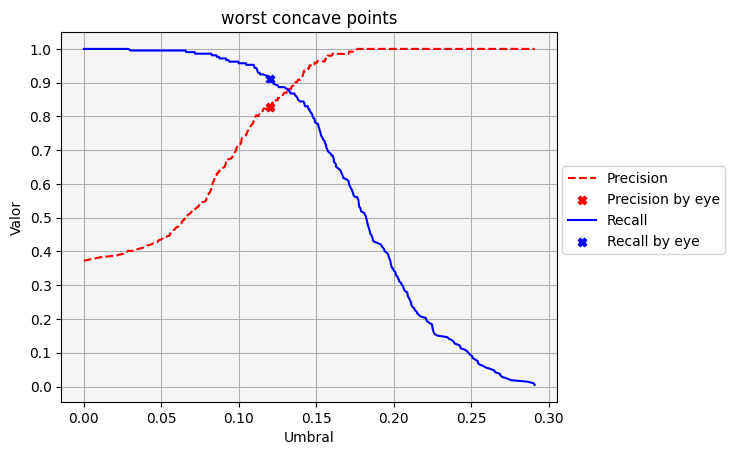

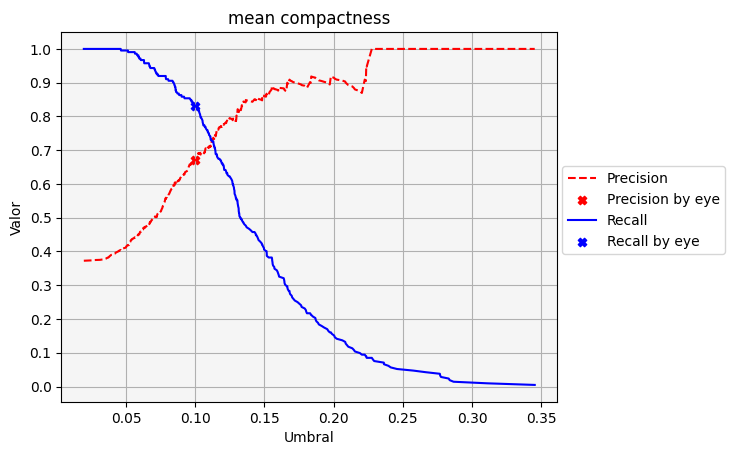

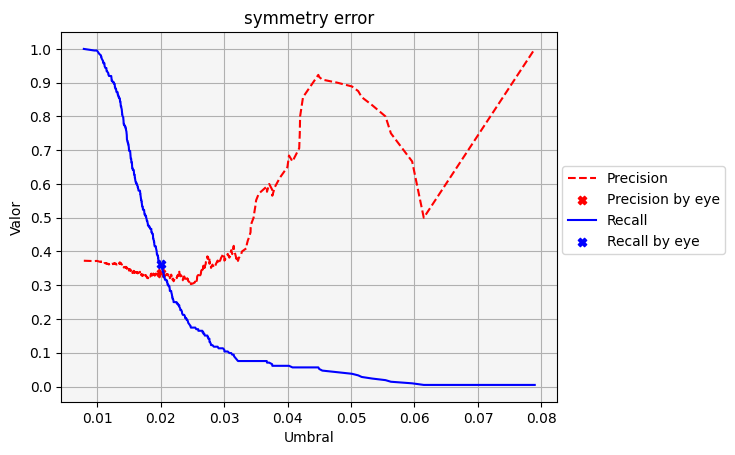

In [76]:
from sklearn.metrics import precision_recall_curve

umbrales = [alta_corr_umbral, media_corr_umbral, baja_corr_umbral]
true = df['target'] # 0 = Benigno, 1 = Maligno

for idx, (name, thresh) in enumerate(zip(variables, umbrales)):
    y_val_recall = df_metricas.iloc[idx]['recall']
    y_val_precision = df_metricas.iloc[idx]['precision']
    var = df[name]
    precision, recall, thresholds = precision_recall_curve(true, var)
    plt.plot(thresholds, precision[:-1], label="Precision", linestyle="--", color='red')
    plt.scatter(thresh, y_val_precision,marker='X', color='red', label='Precision by eye')
    plt.plot(thresholds, recall[:-1], label="Recall", color='blue')
    plt.scatter(thresh, y_val_recall, marker='X', color='blue', label='Recall by eye')
    plt.title(name)
    plt.xlabel("Umbral")
    plt.ylabel("Valor")
    plt.yticks([i/10 for i in range(11)])
    plt.grid(True)
    plt.legend(loc=(1.01,0.4))
    ax = plt.gca()  # Get the current axes
    ax.set_facecolor("whitesmoke")
    plt.show()